In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
from pathlib import Path
import matplotlib.pyplot as plt
from os import getcwd, chdir

PATH = Path.cwd().parent

In [6]:
df = pd.read_csv(f"{PATH}/data/super_conductors_raw.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21263 entries, 0 to 21262
Data columns (total 82 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   number_of_elements               21263 non-null  int64  
 1   mean_atomic_mass                 21263 non-null  float64
 2   wtd_mean_atomic_mass             21263 non-null  float64
 3   gmean_atomic_mass                21263 non-null  float64
 4   wtd_gmean_atomic_mass            21263 non-null  float64
 5   entropy_atomic_mass              21263 non-null  float64
 6   wtd_entropy_atomic_mass          21263 non-null  float64
 7   range_atomic_mass                21263 non-null  float64
 8   wtd_range_atomic_mass            21263 non-null  float64
 9   std_atomic_mass                  21263 non-null  float64
 10  wtd_std_atomic_mass              21263 non-null  float64
 11  mean_fie                         21263 non-null  float64
 12  wtd_mean_fie      

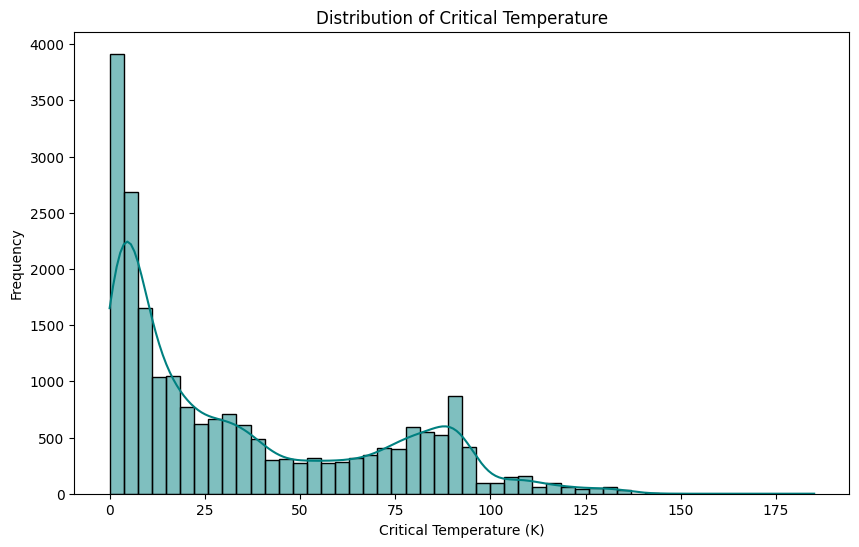

In [7]:
plt.figure(figsize=(10, 6))
sns.histplot(df['critical_temp'], bins=50, kde=True, color='teal')
plt.title('Distribution of Critical Temperature')
plt.xlabel('Critical Temperature (K)')
plt.ylabel('Frequency')
plt.show()

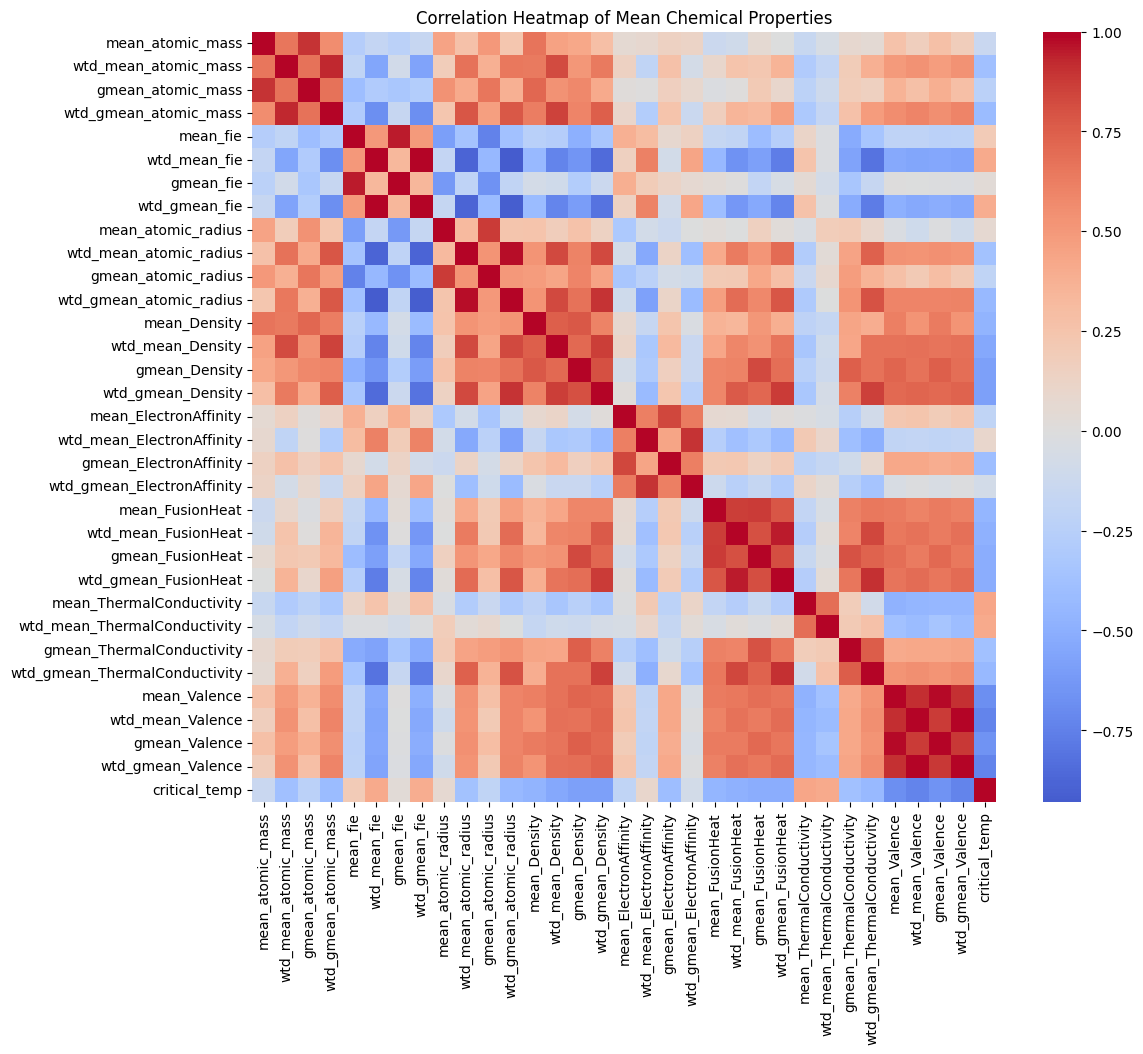

In [8]:
# Select a subset of 'mean' features to avoid a messy 81x81 grid
mean_cols = [col for col in df.columns if 'mean' in col] + ['critical_temp']
corr_matrix = df[mean_cols].corr('spearman')

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap of Mean Chemical Properties')
plt.show()

/tmp/ipykernel_20438/2256965846.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='number_of_elements', y='critical_temp', data=df, palette='viridis')


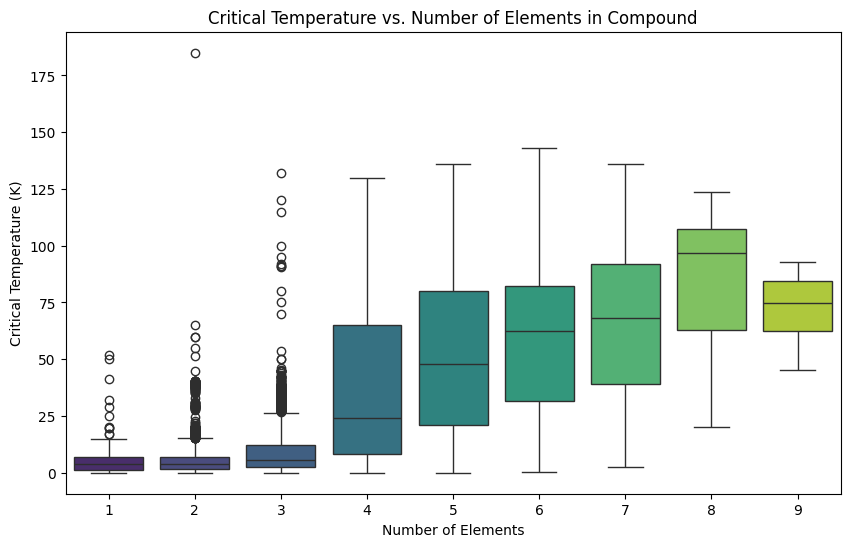

In [15]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='number_of_elements', y='critical_temp', data=df, palette='viridis')
plt.title('Critical Temperature vs. Number of Elements in Compound')
plt.xlabel('Number of Elements')
plt.ylabel('Critical Temperature (K)')
plt.show()

<Figure size 1200x1000 with 0 Axes>

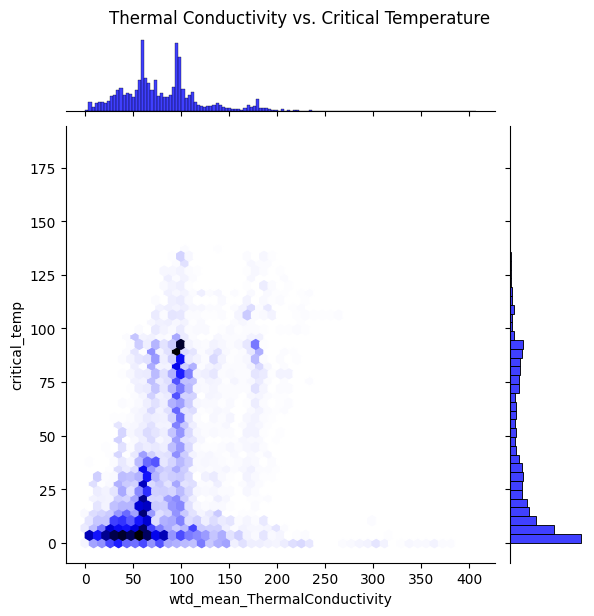

In [18]:
# Visualizing weighted mean thermal conductivity vs temperature
plt.figure(figsize=(12, 10))
sns.jointplot(x='wtd_mean_ThermalConductivity', y='critical_temp', 
              data=df, kind='hex', color='blue')
plt.suptitle('Thermal Conductivity vs. Critical Temperature', y=1.02)
plt.show()